<a href="https://colab.research.google.com/github/lara-ms/Curso_ML/blob/main/notebooks/regress%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regressão linear

Vamos encontrar o melhor modelo polinomial (grau e pesos) usando *k-fold*.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline

## 1. Geração dos dados

In [2]:
# Reset pseudo random generator to a known value so that results are reproducible.
seed = 42
np.random.seed(seed)

In [3]:
# Dataset size.
N = 100

# Generate the feature.
X = 6*np.random.rand(N,1) - 3

# True model (second order function).
y = 2 + X + 0.5*X**2

# Noise.
w = np.random.randn(N, 1)

# Observable function. Noisy version of the true model.
y_noisy = y + w

### **Usaremos a versão ruidosa para treinar um modelo que capture o comportamento geral por trás dos dados.**

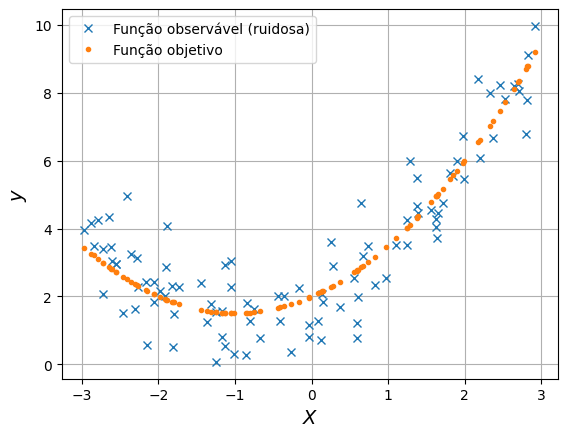

In [4]:
# Plot original data versus noisy version.
plt.plot(X, y_noisy, 'x', label='Função observável (ruidosa)')
plt.plot(X, y, '.', label='Função objetivo')
plt.xlabel('$X$', fontsize=14)
plt.ylabel('$y$', fontsize=14)
plt.legend()
plt.grid()
# Show the plot.
plt.show()

## 2. Divisão do dataset entre treino e teste

**OBS**.: 90% para treinamento e 10% para teste.

In [ ]:
# Divide o dataset em treinamento e teste
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y_noisy.flatten(), test_size=0.1, random_state=seed)

## 3. Validação cruzada: k-fold

Usaremos k-fold para analisar o desempenho de polinômios de ordem 1 até 31.

In [ ]:
# Ordem de polinômios de 1 a 30.
degrees = list(range(1, 31))

# Listas para armazenar os erros de treinamento e validação.
train_errors = []
val_errors = []

train_std = []
val_std = []

# Objeto da classe KFold com k=10.
k = 10
kf = KFold(n_splits=k, shuffle=True, random_state=seed)

# Laço variando os graus dos polinômios.
for deg in degrees:
    # armazenar erro médio por fold
    fold_train_err = []
    fold_val_err = []

    # Treina o modelo com k-1 partes e valida com uma parte k vezes.
    for train_idx, val_idx in kf.split(X_train_full): # retorna os índices dos folds de treinamento e validação a cada iteração.
        X_train = X_train_full[train_idx]
        y_train = y_train_full[train_idx]
        X_val = X_train_full[val_idx]
        y_val = y_train_full[val_idx]

        # Pipeline: matriz polinômial + padronização + SGD
        model = make_pipeline(
            PolynomialFeatures(degree=deg, include_bias=False), # include_bias já é feito pelo SGDRegressor (ver anexo II)
            StandardScaler(),
            SGDRegressor(penalty=None, random_state=seed)
        )

        # Treinar
        model.fit(X_train, y_train)

        # Predição
        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)

        # Calcular MSE para os conjuntos de treinamento e validação.
        fold_train_err.append(mean_squared_error(y_train, y_train_pred))
        fold_val_err.append(mean_squared_error(y_val, y_val_pred))

    # Média dos folds
    train_errors.append(np.mean(fold_train_err))
    val_errors.append(np.mean(fold_val_err))

    # Desvio padrão dos folds
    train_std.append(np.std(fold_train_err))
    val_std.append(np.std(fold_val_err))

## 5. Apresentação dos resultados da validação cruzada

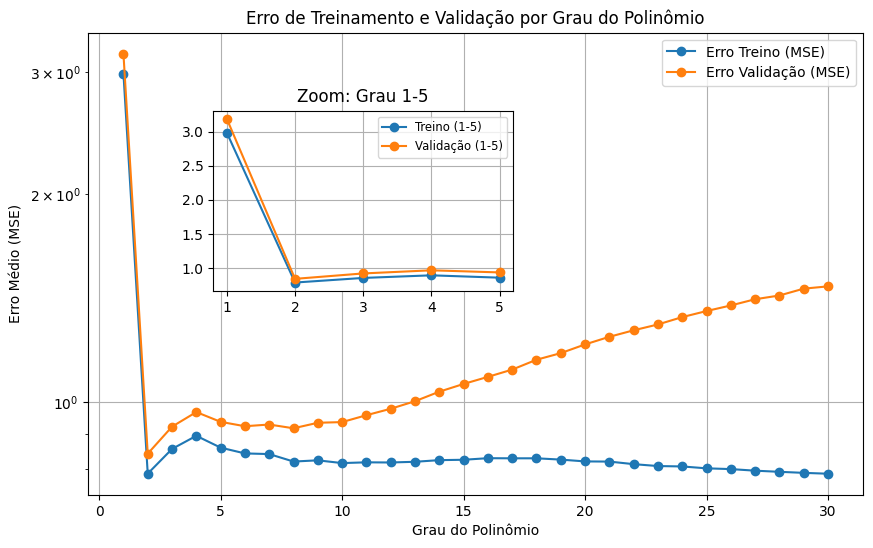

In [ ]:
# Plot do erro vs grau do polinômio
fig, ax_main = plt.subplots(figsize=(10, 6))

# gráfico principal (1 a 30)
ax_main.plot(degrees, train_errors, label='Erro Treino (MSE)', marker='o')
ax_main.plot(degrees, val_errors, label='Erro Validação (MSE)', marker='o')
ax_main.set_yscale('log')
ax_main.set_xlabel('Grau do Polinômio')
ax_main.set_ylabel('Erro Médio (MSE)')
ax_main.set_title('Erro de Treinamento e Validação por Grau do Polinômio')
ax_main.legend()
ax_main.grid(True)

# inset para ordens 1 a 5
left, bottom, width, height = [0.25, 0.45, 0.3, 0.3]  # posição na figura (relativo)
ax_inset = fig.add_axes([left, bottom, width, height])

# selecionar apenas indices 1 a 5
idx_small = [i for i, deg in enumerate(degrees) if deg <= 5]
small_deg = [degrees[i] for i in idx_small]
small_train_err = [train_errors[i] for i in idx_small]
small_val_err = [val_errors[i] for i in idx_small]

ax_inset.plot(small_deg, small_train_err, label='Treino (1-5)', marker='o')
ax_inset.plot(small_deg, small_val_err, label='Validação (1-5)', marker='o')
ax_inset.set_title('Zoom: Grau 1-5')
ax_inset.set_xticks(small_deg)
ax_inset.grid(True)
ax_inset.legend(fontsize='small')

plt.show()

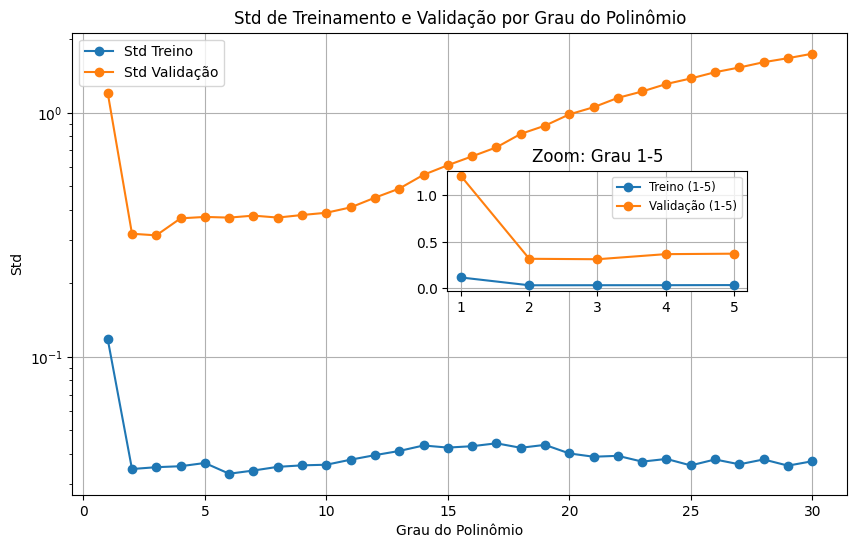

In [ ]:
# Plot do erro vs grau do polinômio
fig, ax_main = plt.subplots(figsize=(10, 6))

# gráfico principal (1 a 30)
ax_main.plot(degrees, train_std, label='Std Treino', marker='o')
ax_main.plot(degrees, val_std, label='Std Validação', marker='o')
ax_main.set_yscale('log')
ax_main.set_xlabel('Grau do Polinômio')
ax_main.set_ylabel('Std')
ax_main.set_title('Std de Treinamento e Validação por Grau do Polinômio')
ax_main.legend()
ax_main.grid(True)

# inset para ordens 1 a 5
left, bottom, width, height = [0.5, 0.45, 0.3, 0.2]  # posição na figura (relativo)
ax_inset = fig.add_axes([left, bottom, width, height])

# selecionar apenas indices 1 a 5
idx_small = [i for i, deg in enumerate(degrees) if deg <= 5]
small_deg = [degrees[i] for i in idx_small]
small_train_err = [train_std[i] for i in idx_small]
small_val_err = [val_std[i] for i in idx_small]

ax_inset.plot(small_deg, small_train_err, label='Treino (1-5)', marker='o')
ax_inset.plot(small_deg, small_val_err, label='Validação (1-5)', marker='o')
ax_inset.set_title('Zoom: Grau 1-5')
ax_inset.set_xticks(small_deg)
ax_inset.grid(True)
ax_inset.legend(fontsize='small')

plt.show()

## 6. Melhor grau

In [ ]:
# Melhor grau
best_degree = degrees[np.argmin(val_errors)]
print(f"Melhor grau de polinômio segundo validação: {best_degree}")

Melhor grau de polinômio segundo validação: 2


## 7. Resultado final

In [ ]:
# Treinar esse melhor modelo com todo o conjunto de treinamento
best_model = make_pipeline(
    PolynomialFeatures(degree=best_degree, include_bias=False),
    StandardScaler(),
    SGDRegressor(random_state=seed)
)
best_model.fit(X_train_full, y_train_full)

# Avaliar no conjunto de treinamento
y_train_pred = best_model.predict(X_train_full)
train_error = mean_squared_error(y_train_full, y_train_pred)
print(f"Erro no conjunto de treinamento (MSE) com grau {best_degree}: {train_error:.4f}")

# Avaliar no conjunto de teste
y_test_pred = best_model.predict(X_test)
test_error = mean_squared_error(y_test, y_test_pred)
print(f"Erro no conjunto de teste (MSE) com grau {best_degree}: {test_error:.4f}")

Erro no conjunto de treinamento (MSE) com grau 2: 0.7902
Erro no conjunto de teste (MSE) com grau 2: 0.7027


## 8. Comparação da melhor aproximação encontrada com as versões original e ruidosa

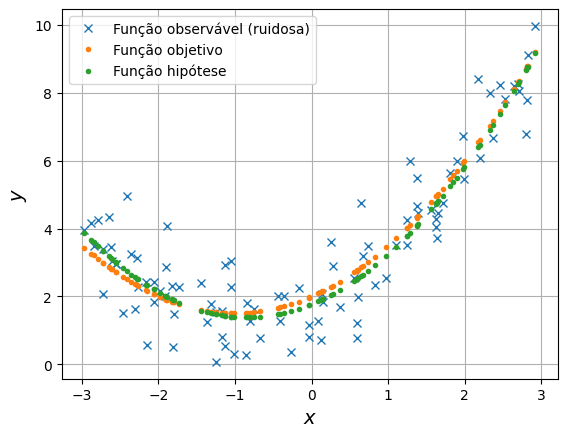

In [ ]:
# Predição com todo o conjunto original
y_pred = best_model.predict(X)

plt.plot(X, y_noisy, 'x', label='Função observável (ruidosa)')
plt.plot(X, y, '.', label='Função objetivo')
plt.plot(X, y_pred, '.', label='Função hipótese')
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$y$', fontsize=14)
plt.legend()
plt.grid()
# Show the plot.
plt.show()